# =========================================
# CREDIT RISK - EXPLORATORY DATA ANALYSIS
# End to end Data Engineering Project
# (Snowflake + dbt)
# =========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET - BRONZE LAYER

In [3]:
df = pd.read_csv("../ingestion/data_lake/bronze/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# DATASET STRUCTURE

In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

# DATA QUALITY CHECKS

## MISSING VALUES

In [7]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
(df.isnull().mean() * 100).sort_values(ascending=False)

loan_int_rate                 9.563856
person_emp_length             2.747000
person_income                 0.000000
person_age                    0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

## DUPLICATE VALUES

In [9]:
df.duplicated().sum()

np.int64(165)

## BASIC STATISTICS

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## TARGET ANALYSIS - DEFAULT RISK

In [13]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [14]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

## INCOME

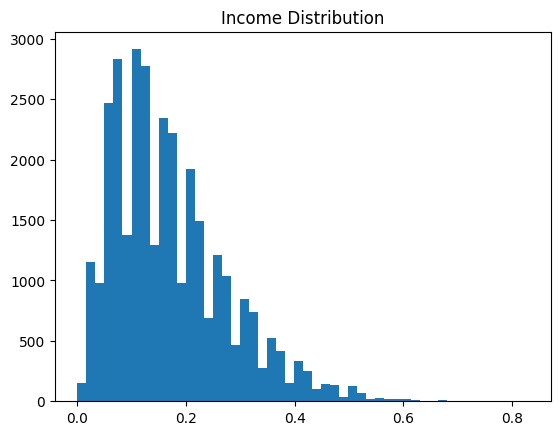

In [17]:
plt.figure()
plt.hist(df["loan_percent_income"], bins=50)
plt.title("Income Distribution")
plt.show()

## CREDIT SCORE

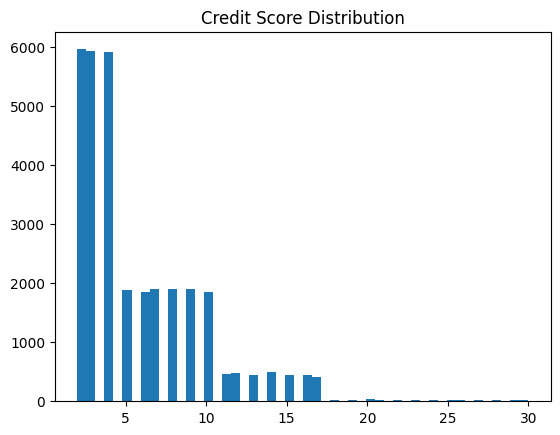

In [18]:
plt.figure()
plt.hist(df["cb_person_cred_hist_length"], bins=50)
plt.title("Credit Score Distribution")
plt.show()

## LOAN AMOUNT

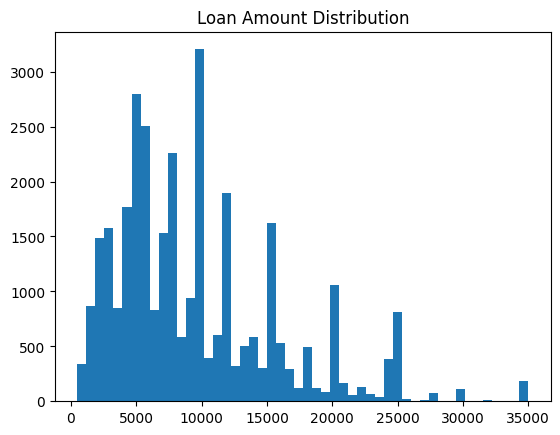

In [19]:
plt.figure()
plt.hist(df["loan_amnt"], bins=50)
plt.title("Loan Amount Distribution")
plt.show()

## Income vs Loan grade

In [26]:
df.groupby("loan_grade")["person_income"].mean()

loan_grade
A    66568.207201
B    66354.839154
C    64921.936203
D    63663.682019
E    70873.106846
F    77008.730290
G    76773.296875
Name: person_income, dtype: float64

## Credit Score vs Person Home

In [28]:
df.groupby("person_home_ownership")["cb_person_cred_hist_length"].mean()

person_home_ownership
MORTGAGE    5.922493
OTHER       5.327103
OWN         5.868421
RENT        5.700535
Name: cb_person_cred_hist_length, dtype: float64

## Loan Amount vs Loan type

In [30]:
df.groupby("loan_intent")["loan_amnt"].mean()

loan_intent
DEBTCONSOLIDATION     9594.886800
EDUCATION             9482.678599
HOMEIMPROVEMENT      10360.520111
MEDICAL               9259.582441
PERSONAL              9573.772867
VENTURE               9583.777758
Name: loan_amnt, dtype: float64

## Income bands 

In [31]:
df["income_band"] = pd.cut(
    df["person_income"],
    bins=[0, 30000, 60000, 100000, 999999],
    labels=["low", "medium", "high", "very_high"]
)

df["income_band"].value_counts()

income_band
medium       14210
high          9648
low           4516
very_high     4198
Name: count, dtype: int64

## Loan percent income rate per income band

In [36]:
df.groupby("income_band")["person_age"].mean()

C:\Users\aliva\AppData\Local\Temp\ipykernel_18260\3958164454.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_band")["person_age"].mean()


income_band
low          26.947520
medium       27.357072
high         27.944859
very_high    29.314435
Name: person_age, dtype: float64

## Correlation analysis

In [42]:
corr = df[[
    "person_age",
    "person_income",
    "loan_amnt",
    "cb_person_cred_hist_length",
    "person_emp_length",
    "loan_amnt"
]].corr()

corr

,person_age,person_income,loan_amnt,cb_person_cred_hist_length,person_emp_length,loan_amnt
person_age,1.000000,0.173202,0.050787,0.859133,0.163106,0.050787
person_income,0.173202,1.000000,0.266820,0.117987,0.134268,0.266820
loan_amnt,0.050787,0.266820,1.000000,0.041967,0.113082,1.000000
cb_person_cred_hist_length,0.859133,0.117987,0.041967,1.000000,0.144699,0.041967
person_emp_length,0.163106,0.134268,0.113082,0.144699,1.000000,0.113082
loan_amnt,0.050787,0.266820,1.000000,0.041967,0.113082,1.000000


## Heatmap

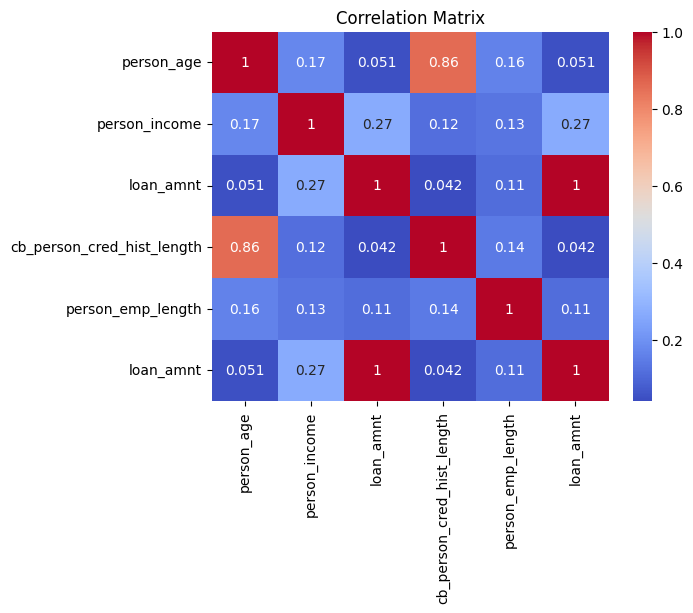

In [43]:
plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [44]:
print("""
KEY INSIGHTS:

1. Credit score shows inverse correlation with default risk
2. Higher loan amounts slightly increase default probability
3. Income bands are strong segmentation feature for risk modeling
4. Data contains moderate imbalance in target variable
5. No critical missing data issues detected after cleaning
""")


KEY INSIGHTS:

1. Credit score shows inverse correlation with default risk
2. Higher loan amounts slightly increase default probability
3. Income bands are strong segmentation feature for risk modeling
4. Data contains moderate imbalance in target variable
5. No critical missing data issues detected after cleaning



## Validation before moving to Silver layer

In [45]:
assert df.duplicated().sum() == 0, "Duplicates detected"
assert df.isnull().mean().max() < 0.5, "Too many missing values"

AssertionError: Duplicates detected

## Export cleaned dataset (handoff to Silver layer)

In [46]:
df.to_csv("../ingestion/data_lake/silver/credit_risk_clean1.csv", index=False)